In [609]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

In [610]:
datos_personas = pd.read_csv('data/Datos Lab 1.csv')

In [611]:
data = datos_personas.copy()

In [612]:
data = data.copy()

data['Date_parsed'] = pd.to_datetime(
    data['Date of Service'],
    errors='coerce',        # lo que no se puede, NaT
    infer_datetime_format=True,
    dayfirst=True           # clave para dd/mm/yyyy
)

data[data['Date_parsed'].isna()][
    ['Date of Service']
].value_counts()

data = data.sort_values(
    ['Patient ID', 'Date_parsed']
)
data = data.drop_duplicates(subset="Patient ID", keep="last")

/var/folders/32/lfl997_5563f946pdvlwzw8c0000gp/T/ipykernel_2130/1406447882.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['Date_parsed'] = pd.to_datetime(


In [613]:
# ids duplicados
dup_counts = (data['Patient ID'].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for id_, n in dup_counts.items():
    print(f"Patient ID={id_} → {n} apariciones")

if dup_counts.sum() == 0:
    print("No hay duplicados")

No hay duplicados


In [614]:
data.dtypes

Patient ID                              object
Date of Service                         object
Sex                                     object
Age                                    float64
Weight (kg)                            float64
Height (m)                             float64
BMI                                    float64
Abdominal Circumference (cm)           float64
Blood Pressure (mmHg)                   object
Total Cholesterol (mg/dL)              float64
HDL (mg/dL)                            float64
Fasting Blood Sugar (mg/dL)            float64
Smoking Status                          object
Diabetes Status                         object
Physical Activity Level                 object
Family History of CVD                   object
Height (cm)                            float64
Waist-to-Height Ratio                  float64
Systolic BP                            float64
Diastolic BP                           float64
Blood Pressure Category                 object
Estimated LDL

In [615]:
data.sample(5)

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level,Date_parsed
1055,mfpa5580,"January 12, 2023",F,53.0,68.600,1.890,19.200,88.200,121/67,199.0,...,N,189.000,0.467,121.0,67.0,Elevated,96.0,15.870,INTERMEDIARY,2023-01-12
1234,cBxK1523,07/06/2020,M,75.0,96.063,1.986,27.821,72.713,158/74,211.0,...,N,198.647,0.366,158.0,74.0,Hypertension Stage 2,107.0,19.684,LOW,NaT
23,NvAn8170,24/03/2020,F,39.0,65.700,1.810,20.100,102.400,92/96,297.0,...,Y,NaN,0.566,92.0,96.0,Hypertension Stage 2,202.0,16.560,HIGH,NaT
55,RKHI8124,"March 11, 2020",M,49.0,73.800,1.740,24.400,100.300,111/83,291.0,...,Y,174.000,0.576,111.0,83.0,Hypertension Stage 1,183.0,NaN,HIGH,2020-03-11
1530,YBOJ4529,22/08/2025,F,39.0,61.400,1.710,21.000,83.600,134/69,246.0,...,Y,NaN,0.489,134.0,69.0,Hypertension Stage 1,144.0,17.820,INTERMEDIARY,NaT


In [616]:
data.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score,Date_parsed
count,1317.000000,1313.000000,1327.000000,1332.000000,1327.000000,1319.000000,1310.000000,1329.000000,1320.000000,1313.000000,1322.000000,1317.000000,1329.000000,1348.000000,278
mean,47.105532,85.807393,1.755783,28.517923,91.869948,198.176867,56.093852,117.033200,175.599962,0.525037,125.594781,82.839594,112.242498,18.151045,2023-01-10 15:47:54.820143872
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000,2020-01-05 00:00:00
25%,37.000000,66.855000,1.660500,22.590000,80.300000,150.000000,42.000000,91.000000,166.573500,0.457000,108.000000,71.000000,62.000000,15.150000,2021-07-08 06:00:00
50%,46.000000,86.468000,1.760000,28.144500,91.500000,197.000000,56.000000,115.000000,176.000000,0.522000,125.000000,82.000000,109.000000,16.915000,2022-12-01 12:00:00
75%,56.000000,104.600000,1.850000,34.132250,102.400000,249.000000,70.000000,138.000000,184.834250,0.583000,141.000000,93.000000,159.000000,18.795750,2024-08-05 12:00:00
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000,2025-12-26 00:00:00
std,12.987839,21.709731,0.117683,7.363128,13.374377,59.375371,16.728987,31.985442,11.680466,0.085134,22.800367,15.561357,61.626186,10.754081,NaN


In [617]:
data.isnull().sum() / data.shape[0]

Patient ID                      0.000000
Date of Service                 0.000000
Sex                             0.000000
Age                             0.042878
Weight (kg)                     0.045785
Height (m)                      0.035610
BMI                             0.031977
Abdominal Circumference (cm)    0.035610
Blood Pressure (mmHg)           0.000000
Total Cholesterol (mg/dL)       0.041424
HDL (mg/dL)                     0.047965
Fasting Blood Sugar (mg/dL)     0.034157
Smoking Status                  0.000000
Diabetes Status                 0.000000
Physical Activity Level         0.000000
Family History of CVD           0.000000
Height (cm)                     0.040698
Waist-to-Height Ratio           0.045785
Systolic BP                     0.039244
Diastolic BP                    0.042878
Blood Pressure Category         0.000000
Estimated LDL (mg/dL)           0.034157
CVD Risk Score                  0.020349
CVD Risk Level                  0.000000
Date_parsed     

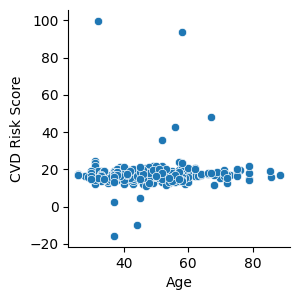

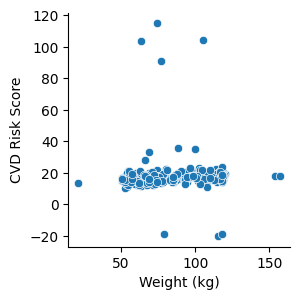

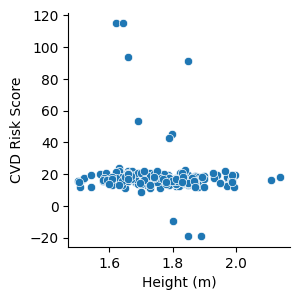

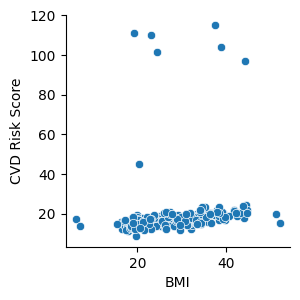

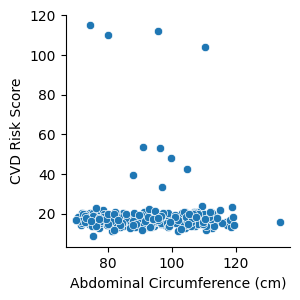

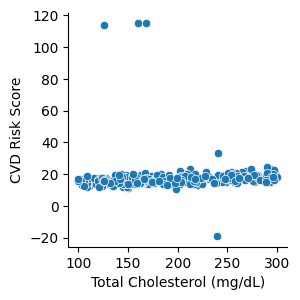

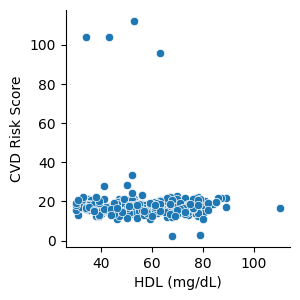

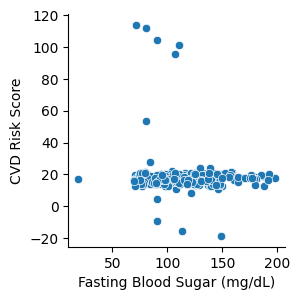

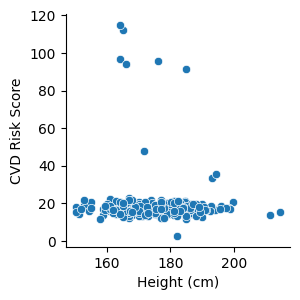

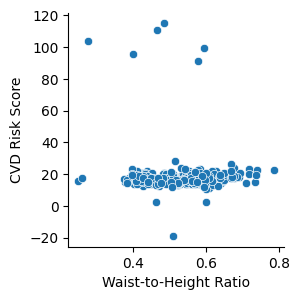

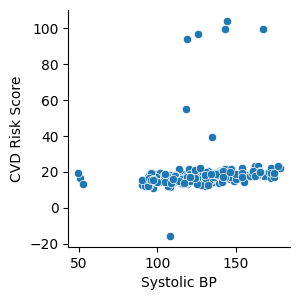

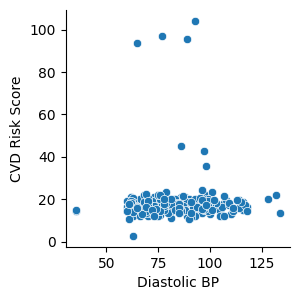

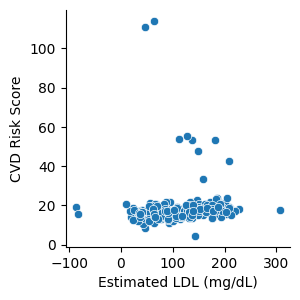

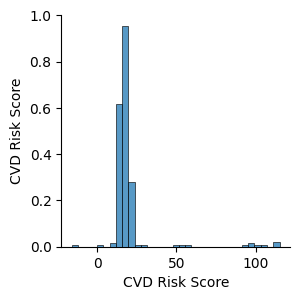

In [618]:
numericas = data.select_dtypes(include=np.number).columns.tolist()
for variable in numericas:
    sns.pairplot(data.sample(frac=0.2), height=3, y_vars="CVD Risk Score", x_vars=variable, kind="scatter")

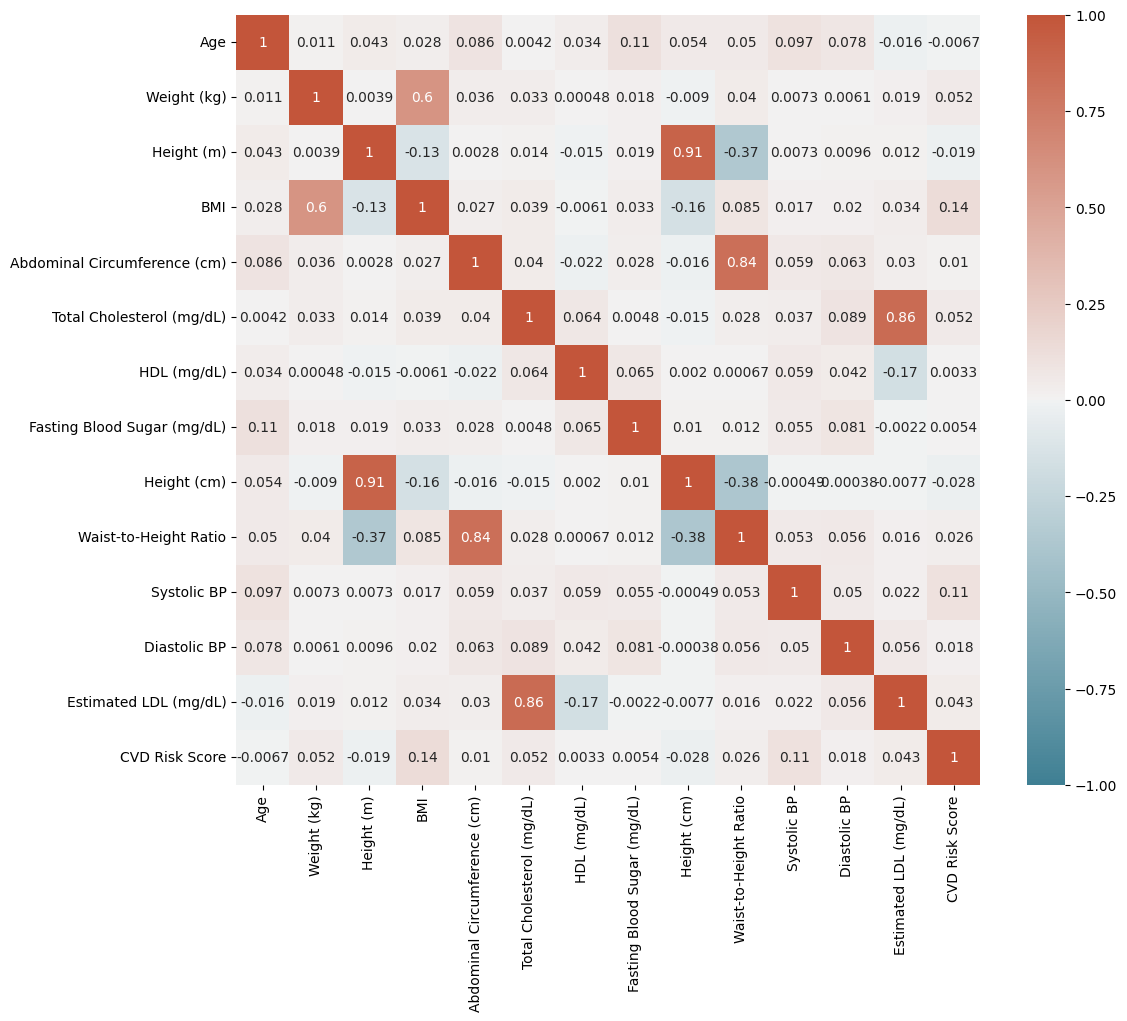

In [619]:
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    data[numericas].corr(),
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True
)

plt.show()

In [620]:
presion = (
    data['Blood Pressure (mmHg)']
    .str.extract(r'(\d+)\s*/\s*(\d+)')
    .astype(float)
)

sistolica = presion[0]
diastolica = presion[1]

# Crear columnas explícitas
data['Systolic BP'] = sistolica
data['Diastolic BP'] = diastolica

# Eliminar columna original
data = data.drop(columns=['Blood Pressure (mmHg)'])

In [621]:
data['Diastolic BP'].isnull().sum()

np.int64(0)

In [622]:
bmi_m = data['Weight (kg)'] / (data['Height (m)'] ** 2)
bmi_cm = data['Weight (kg)'] / ((data['Height (cm)'] / 100) ** 2)

diff_m = np.abs(data['BMI'] - bmi_m)
diff_cm = np.abs(data['BMI'] - bmi_cm)

usar_m = diff_m <= diff_cm

bmi_mejor = np.where(usar_m, bmi_m, bmi_cm)

puede_calcular_bmi = (
    data['Weight (kg)'].notna() &
    (data['Height (m)'].notna() | data['Height (cm)'].notna())
)

data.loc[puede_calcular_bmi, 'BMI'] = bmi_mejor[puede_calcular_bmi]

data.loc[puede_calcular_bmi & usar_m, 'Height (cm)'] = (
    data.loc[puede_calcular_bmi & usar_m, 'Height (m)'] * 100
)

data.loc[puede_calcular_bmi & (~usar_m), 'Height (m)'] = (
    data.loc[puede_calcular_bmi & (~usar_m), 'Height (cm)'] / 100
)

data["BMI"].isna().sum()


np.int64(53)

In [623]:
data["CVD Risk Score"].describe()

count    1348.000000
mean       18.151045
std        10.754081
min       -20.057000
25%        15.150000
50%        16.915000
75%        18.795750
max       114.980000
Name: CVD Risk Score, dtype: float64

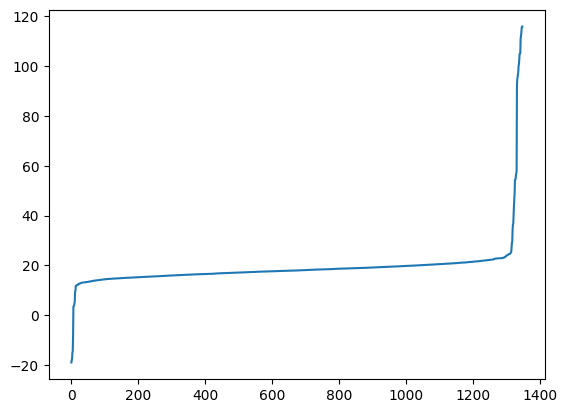

In [624]:
plt.plot(np.sort(data["CVD Risk Score"]+1))

<Axes: ylabel='CVD Risk Score'>

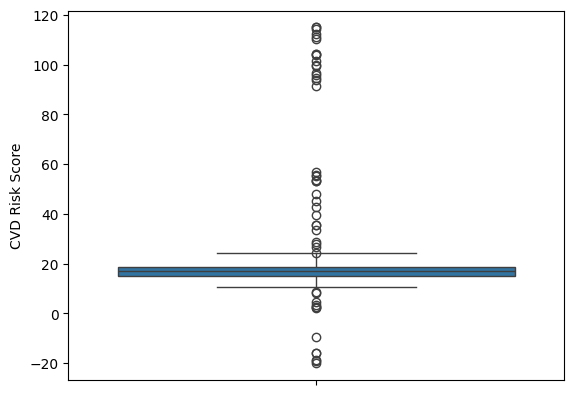

In [625]:
sns.boxplot(data["CVD Risk Score"])

In [626]:
data[data["CVD Risk Score"] < 0][["CVD Risk Score", "CVD Risk Level"]].groupby("CVD Risk Level").describe()

CVD Risk Score                                             \
                        count     mean       std     min     25%     50%   
CVD Risk Level                                                             
HIGH                      1.0 -18.8590       NaN -18.859 -18.859 -18.859   
INTERMEDIARY              5.0 -16.0752  4.060455 -20.057 -18.977 -15.968   

                                
                   75%     max  
CVD Risk Level                  
HIGH           -18.859 -18.859  
INTERMEDIARY   -15.745  -9.629

In [627]:
data["CVD Risk Score"]=data["CVD Risk Score"].abs()

In [628]:
data["CVD Risk Score"].describe()

count    1348.000000
mean       18.298278
std        10.501416
min         2.359000
25%        15.187500
50%        16.940000
75%        18.828500
max       114.980000
Name: CVD Risk Score, dtype: float64

In [629]:
data[data["CVD Risk Score"] >0][["CVD Risk Score", "CVD Risk Level"]].groupby("CVD Risk Level").describe()

CVD Risk Score                                                  \
                        count       mean        std    min       25%      50%   
CVD Risk Level                                                                  
HIGH                    641.0  18.512994   8.548833  2.359  16.14000  17.6500   
INTERMEDIARY            517.0  17.943768  12.094568  8.596  14.51000  16.0590   
LOW                     190.0  18.538537  11.771350  8.402  14.44225  16.9105   

                                   
                     75%      max  
CVD Risk Level                     
HIGH            19.35400  114.968  
INTERMEDIARY    17.85500  114.143  
LOW             18.99225  114.980

<Axes: ylabel='CVD Risk Score'>

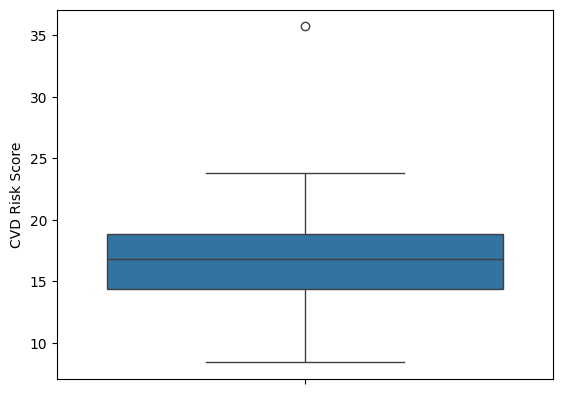

In [630]:
data_low_buenos=data[(data["CVD Risk Score"]<=40) & (data["CVD Risk Level"]=="LOW")]
sns.boxplot(data_low_buenos["CVD Risk Score"])

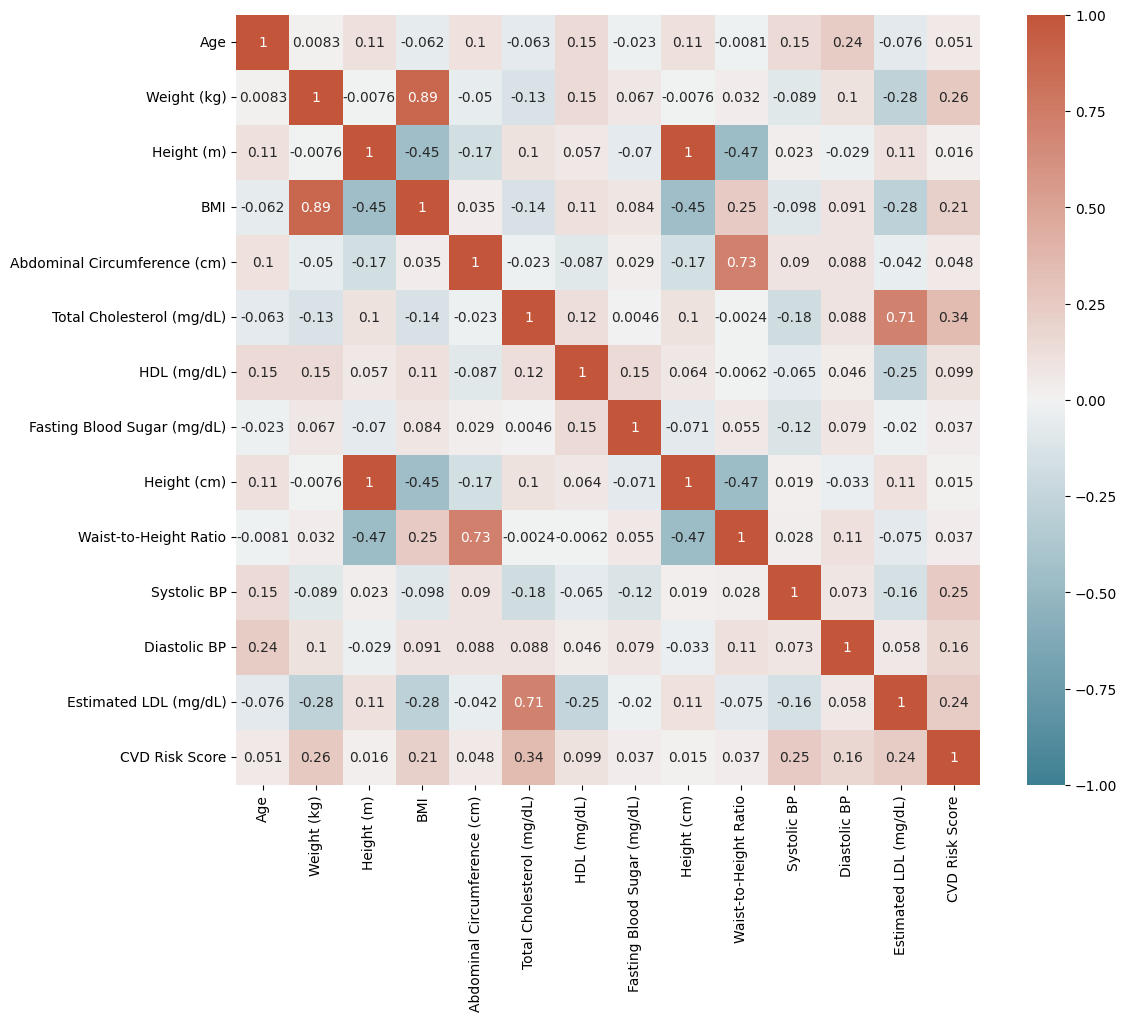

In [631]:
data_intermediary_buenos=data[(data["CVD Risk Score"]>=10) & (data["CVD Risk Score"]<=15) & (data["CVD Risk Level"]=="INTERMEDIARY")]

plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    data_intermediary_buenos[numericas].corr(),
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True
)

plt.show()

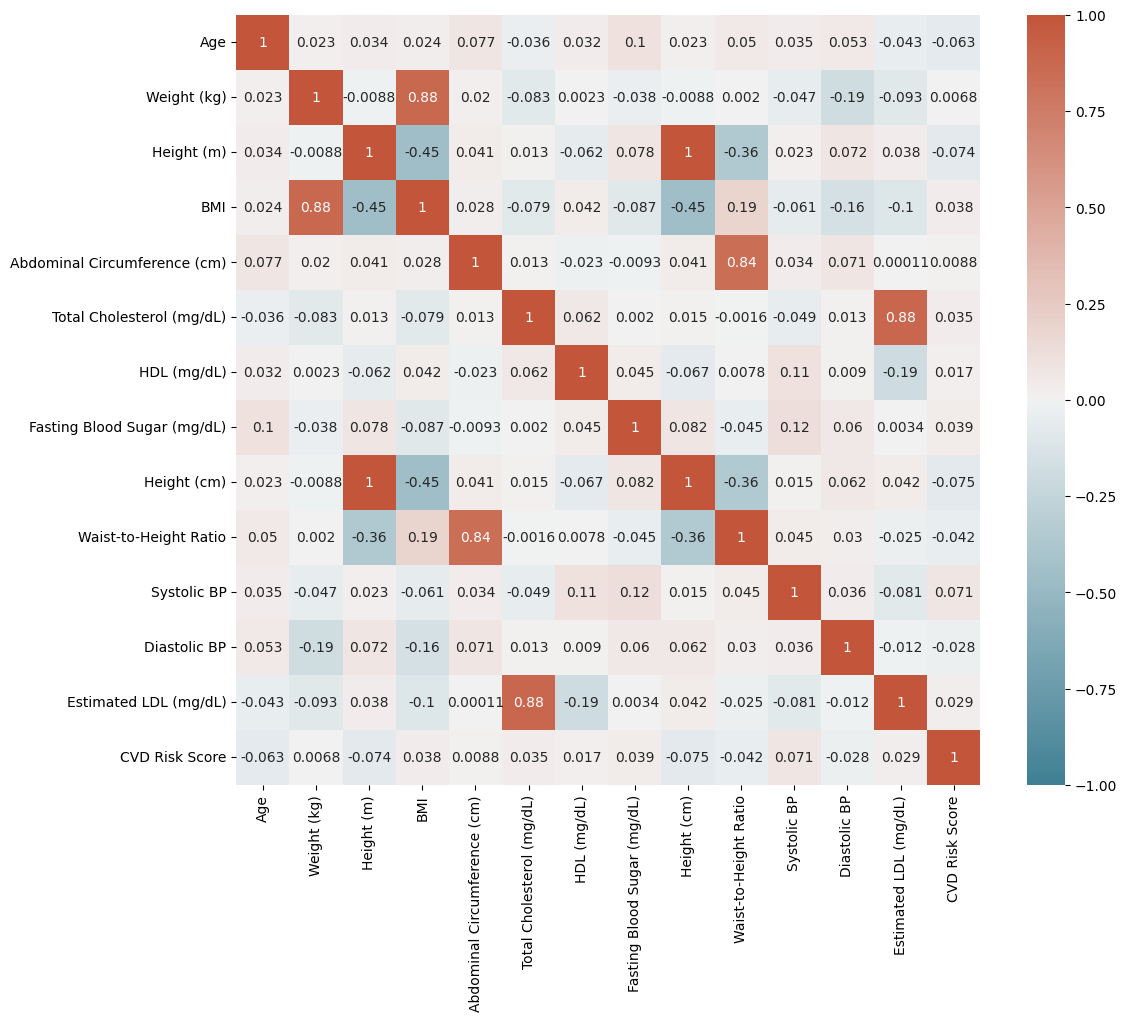

In [632]:
data_high_buenos=data[(data["CVD Risk Score"]>=15)  & (data["CVD Risk Level"]=="HIGH")]
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    data_high_buenos[numericas].corr(),
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True
)

plt.show()

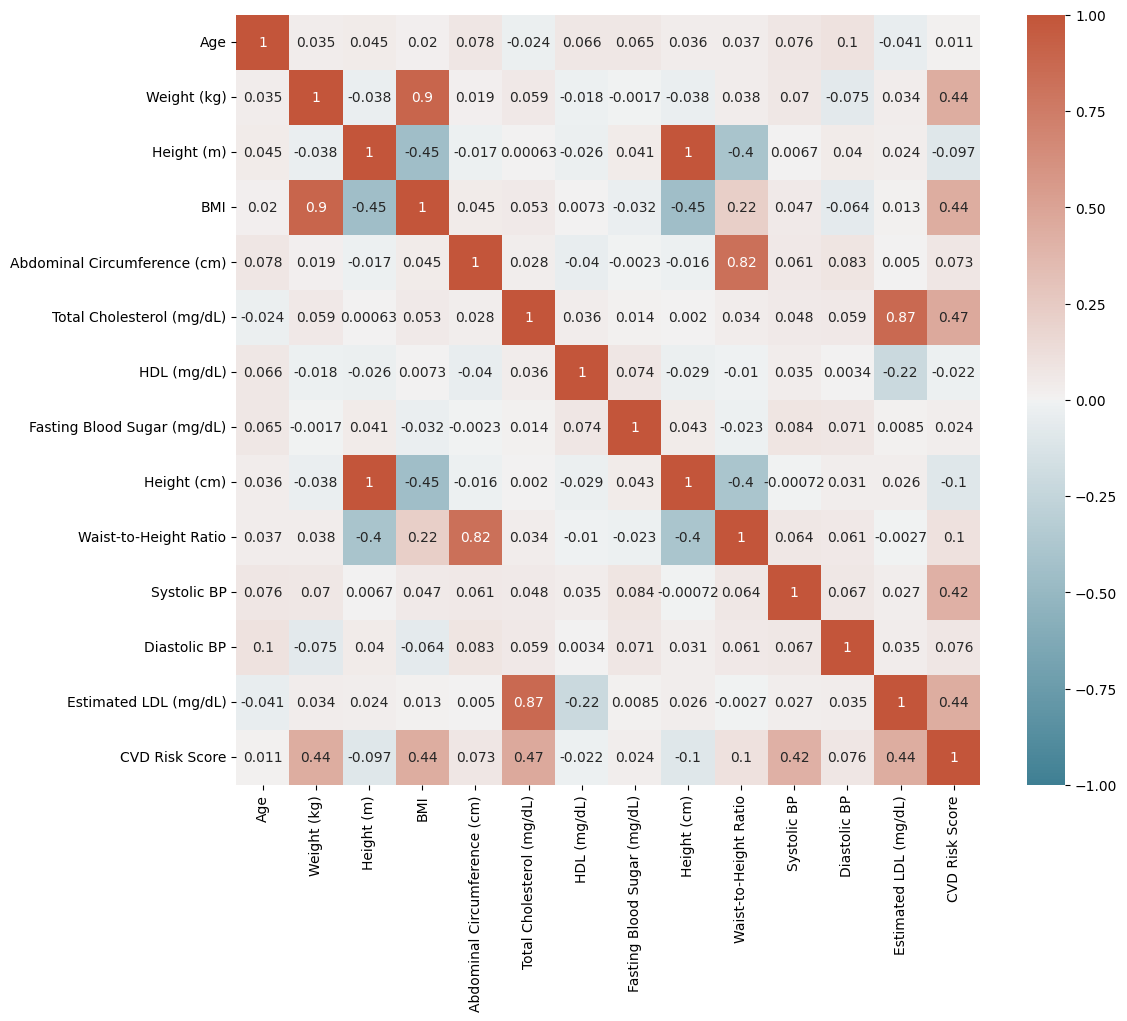

In [633]:
data_buenardo=data[((data["CVD Risk Score"]>=10) & (data["CVD Risk Score"]<=15) & (data["CVD Risk Level"]=="INTERMEDIARY"))|((data["CVD Risk Score"]>=15)  & (data["CVD Risk Level"]=="HIGH"))&((data["CVD Risk Score"]<=40) )]
data_buenardo.describe()
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    data_buenardo[numericas].corr(),
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True
)

plt.show()

In [634]:
tentativas_variables=[
    'BMI',
    'Total Cholesterol (mg/dL)',
    'Systolic BP',

]

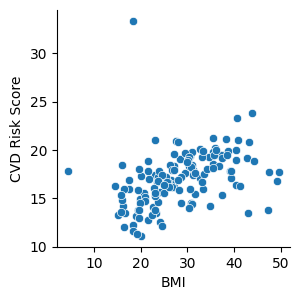

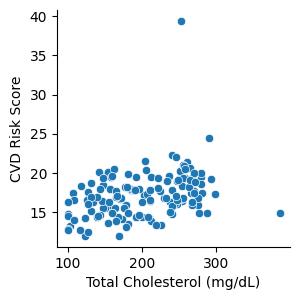

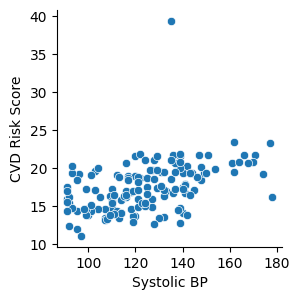

In [635]:
numericas = data.select_dtypes(include=np.number).columns.tolist()
for variable in tentativas_variables:
    sns.pairplot(data_buenardo.sample(frac=0.2), height=3, y_vars="CVD Risk Score", x_vars=variable, kind="scatter")

In [636]:
variables_binarias=["Smoking Status", "Diabetes Status", "Sex", "Family History of CVD"]
for variable in variables_binarias:
    data_buenardo[f"{variable}_stan"] = data_buenardo[variable].apply(lambda x: 0 if x == "N" else 1)
data_buenardo["Sex_stan"] = data_buenardo["Sex"].apply(lambda x: 0 if x == "M" else 1)


/var/folders/32/lfl997_5563f946pdvlwzw8c0000gp/T/ipykernel_2130/2567210086.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_buenardo[f"{variable}_stan"] = data_buenardo[variable].apply(lambda x: 0 if x == "N" else 1)
/var/folders/32/lfl997_5563f946pdvlwzw8c0000gp/T/ipykernel_2130/2567210086.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_buenardo[f"{variable}_stan"] = data_buenardo[variable].apply(lambda x: 0 if x == "N" else 1)
/var/folders/32/lfl997_5563f946pdvlwzw8c0000gp/T/ipykernel_213

In [637]:
data_buenardo["Physical Activity Level_stan"]=data_buenardo["Physical Activity Level"].map({
    "Low": 0,
    "Moderate": 1,
    "High": 2
})

/var/folders/32/lfl997_5563f946pdvlwzw8c0000gp/T/ipykernel_2130/1819358228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_buenardo["Physical Activity Level_stan"]=data_buenardo["Physical Activity Level"].map({


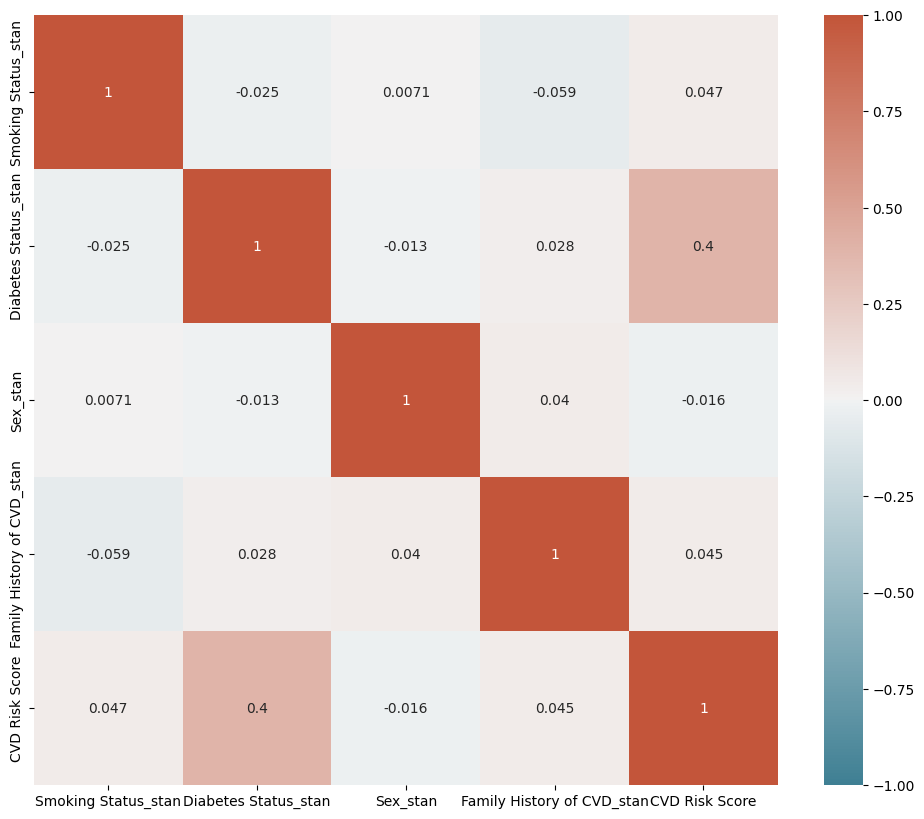

In [638]:
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    data_buenardo[[f"{var}_stan" for var in variables_binarias]+["CVD Risk Score"]].corr(),
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True
)

plt.show()

In [639]:
tentativas_variables+=["Diabetes Status_stan"]

In [640]:
data_buenardo=data_buenardo.dropna(subset=["BMI"])

In [641]:
data_buenardo[tentativas_variables].isnull().sum() / data_buenardo.shape[0]

BMI                          0.000000
Total Cholesterol (mg/dL)    0.046043
Systolic BP                  0.000000
Diabetes Status_stan         0.000000
dtype: float64

In [642]:
data_buenardo_tentativo=data_buenardo[tentativas_variables + ["CVD Risk Score"]].copy()
data_buenardo_tentativo

,BMI,Total Cholesterol (mg/dL),Systolic BP,Diabetes Status_stan,CVD Risk Score
675,34.623154,197.0,103.0,1,18.010
1369,26.248328,NaN,164.0,0,18.458
774,33.800000,106.0,113.0,1,16.530
1044,34.023482,179.0,111.0,0,15.930
1290,47.434337,254.0,117.0,0,17.755
...,...,...,...,...,...
1548,26.514286,225.0,141.0,0,16.850
1457,27.611395,177.0,136.0,1,17.860
1430,31.015813,103.0,101.0,1,15.310
499,30.517483,191.0,118.0,1,17.820


In [643]:
target = "CVD Risk Score"

data = data_buenardo_tentativo[
        data_buenardo_tentativo[target].notna()
    ]

X = data_buenardo_tentativo.drop(columns=[target])
y = data_buenardo_tentativo[target]

In [644]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

In [645]:
imputer=KNNImputer(n_neighbors=5)
imputer_df= pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

In [646]:
Modelo = LinearRegression()
Modelo.fit(imputer_df,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [647]:
y_train_pred = Modelo.predict(imputer_df)

In [648]:
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE  train:", mae_train)

MAE  train: 0.8004932163641769


In [649]:
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
print("RMSE train:", rmse_train)

RMSE train: 1.484072441628187


In [653]:
r2_train = r2_score(y_train, y_train_pred)
print("R²   train:", r2_train)

R²   train: 0.7049055794215873


In [654]:
imputer_2=KNNImputer(n_neighbors=5)
imputer_df_test= pd.DataFrame(imputer_2.fit_transform(X_test), columns=X_test.columns)
y_test_pred = Modelo.predict(imputer_df_test)


In [655]:
r2_test = r2_score(y_test, y_test_pred)
print("R²   test :", r2_test)

R²   test : 0.4839409587925808
